In [1]:
import polars as pl
import requests
import io
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

In [2]:
REGION_DEFAULTS = {
    "NSW1": {"lat": -33.8688, "lon": 151.2093, "tz": "Australia/Sydney"},   # Sydney
    "VIC1": {"lat": -37.8136, "lon": 144.9631, "tz": "Australia/Melbourne"},# Melbourne
    "QLD1": {"lat": -27.4698, "lon": 153.0251, "tz": "Australia/Brisbane"}, # Brisbane
    "SA1":  {"lat": -34.9285, "lon": 138.6007, "tz": "Australia/Adelaide"}, # Adelaide
    "TAS1": {"lat": -42.8821, "lon": 147.3272, "tz": "Australia/Hobart"},   # Hobart
}

def fetch_open_meteo_shortwave_radiation_polars(
    start_dt: datetime,
    end_dt: datetime,
    latitude: float,
    longitude: float,
    timezone: str,
) -> pl.DataFrame:
    """
    Fetch hourly shortwave radiation (W/m^2) from Open-Meteo archive for a date range.
    Returns a Polars DataFrame with columns: ['time', 'shortwave_radiation'].
    """
    url = "https://archive-api.open-meteo.com/v1/archive"
    params = {
        "latitude": latitude,
        "longitude": longitude,
        "start_date": start_dt.date().isoformat(),
        "end_date": end_dt.date().isoformat(),
        "hourly": "shortwave_radiation",
        "timezone": timezone,
    }
    r = requests.get(url, params=params, timeout=60)
    r.raise_for_status()
    data = r.json()
    hourly = data.get("hourly", {})
    times = hourly.get("time", [])
    swr = hourly.get("shortwave_radiation", [])
    if not times or not swr:
        raise ValueError("Open-Meteo returned no hourly radiation data for the requested range.")
    return pl.DataFrame({"time": times, "shortwave_radiation": swr}).with_columns(
        pl.col("time").str.to_datetime().alias("time"),
        pl.col("shortwave_radiation").cast(pl.Float32)
    )

shape: (36, 2)
┌─────────────────────┬─────────────────────┐
│ time                ┆ shortwave_radiation │
│ ---                 ┆ ---                 │
│ datetime[μs]        ┆ f32                 │
╞═════════════════════╪═════════════════════╡
│ 2023-01-01 06:00:00 ┆ 1.0                 │
│ 2023-01-01 07:00:00 ┆ 69.0                │
│ 2023-01-01 08:00:00 ┆ 238.0               │
│ 2023-01-01 09:00:00 ┆ 443.0               │
│ 2023-01-01 10:00:00 ┆ 561.0               │
│ …                   ┆ …                   │
│ 2023-01-03 13:00:00 ┆ 921.0               │
│ 2023-01-03 14:00:00 ┆ 1021.0              │
│ 2023-01-03 15:00:00 ┆ 810.0               │
│ 2023-01-03 16:00:00 ┆ 745.0               │
│ 2023-01-03 17:00:00 ┆ 644.0               │
└─────────────────────┴─────────────────────┘


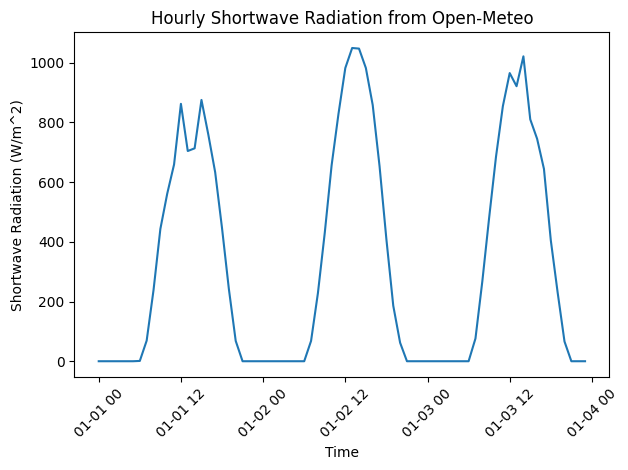

In [8]:
rad_df = fetch_open_meteo_shortwave_radiation_polars(
    start_dt=datetime(2023, 1, 1),
    end_dt=datetime(2023, 1, 3),
    latitude=-33.8688,
    longitude=151.2093,
    timezone="Australia/Sydney"
)
# print times between 6 AM and 6 PM and plot it
print(rad_df.filter(
    (pl.col("time").dt.hour() >= 6) & (pl.col("time").dt.hour() < 18)
))
import matplotlib.pyplot as plt
plt.plot(
    rad_df["time"].to_list(),
    rad_df["shortwave_radiation"].to_list()
)
plt.xlabel("Time")
plt.ylabel("Shortwave Radiation (W/m^2)")
plt.title("Hourly Shortwave Radiation from Open-Meteo")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
def radiation_to_pv_power_polars(
    target_times: pl.Series,
    hourly_radiation_df: pl.DataFrame,
    solar_max_output: float,
) -> np.ndarray:
    """
    Convert shortwave radiation (W/m^2) to PV plant output using a simple linear model:
      PV = solar_max_output * clamp(radiation / 1000, 0..1)
    Interpolates from hourly points onto target_times (as Polars Series).
    Returns a numpy array.
    """
    src_times = hourly_radiation_df["time"].to_numpy()
    src_epoch = np.array([t.astype('datetime64[ns]').astype(np.int64) for t in src_times])
    src_rad = hourly_radiation_df["shortwave_radiation"].to_numpy()
    cf = np.clip(src_rad / 1000.0, 0.0, 1.0)
    pv_hourly = solar_max_output * cf

    tgt_times = target_times.to_numpy()
    tgt_epoch = np.array([t.astype('datetime64[ns]').astype(np.int64) for t in tgt_times])

    pv_interp = np.interp(tgt_epoch, src_epoch, pv_hourly, left=pv_hourly[0], right=pv_hourly[-1])
    return pv_interp.astype(np.float32)

In [ ]:
# Example: Convert radiation to PV output for a 100 MW plant
# Use the rad_df from above and create a target_times series (e.g., every 30 min for 2 days)
import numpy as np
import polars as pl

# Create 30-min intervals for Jan 1-2, 2023
target_times = pl.Series(
    "Time",
    np.arange(
        np.datetime64("2023-01-01T00:00"),
        np.datetime64("2023-01-03T00:00"),
        np.timedelta64(30, "m")
    )
)

pv = radiation_to_pv_power_polars(
    target_times=target_times,
    hourly_radiation_df=rad_df,
    solar_max_output=100.0  # 100 MW
)
print(pv[:10])  # Show first 10 values

In [ ]:
def fetch_aemo_aggregated_data(year: int, month: int, region: str) -> pl.DataFrame:
    """
    Fetches aggregated price and demand data directly from AEMO's CSV archive.
    
    Args:
        year: The year to fetch (e.g., 2023)
        month: The month to fetch (e.g., 1 for January)
        region: The NEM region (e.g., 'NSW1', 'VIC1', 'QLD1', 'SA1', 'TAS1')
        
    Returns:
        pl.DataFrame: Raw Polars DataFrame containing the CSV data.
    """
    # Format: PRICE_AND_DEMAND_YYYYMM_REGION.csv
    month_str = f"{month:02d}"
    url = f"https://aemo.com.au/aemo/data/nem/priceanddemand/PRICE_AND_DEMAND_{year}{month_str}_{region}.csv"
    
    print(f"Fetching data from: {url}")
    try:
        response = requests.get(url)
        response.raise_for_status()
        
        # Read content into Polars
        # Using pandas first for robust CSV parsing of web streams, then converting to Polars
        # (Polars read_csv sometimes requires a file-like object with specific traits)
        pdf = pd.read_csv(io.StringIO(response.content.decode('utf-8')))
        df = pl.from_pandas(pdf)
        return df
        
    except requests.exceptions.HTTPError as e:
        print(f"Failed to download data: {e}")
        print("Note: AEMO data is generally available for the last ~20 years. Ensure the date is valid.")
        return None
    except Exception as e:
        print(f"An error occurred: {e}")
        return None

In [ ]:
# Example: Fetch AEMO price and demand data for NSW1, Jan 2023
df_raw = fetch_aemo_aggregated_data(2023, 1, "NSW1")
print(df_raw.head())

In [ ]:


def prepare_grid_sim_data(
    df: pl.DataFrame,
    forecast_horizon_steps: int = 48,
    solar_trace: np.array = None,
    *,
    region: str = None,
    latitude: float = None,
    longitude: float = None,
    timezone: str = None,
    solar_max_output: float = 0.0,
) -> pl.DataFrame:
    """
    Transforms raw AEMO data into the format expected by SolarBatteryEnv/GridBatteryEnv.
    If solar_trace is None and solar_max_output > 0, fetches solar radiation for the
    timestamp range + location and synthesizes SolarGen.
    """
    q = (
        df.lazy()
        .select([
            pl.col("SETTLEMENTDATE").str.to_datetime(format="%Y/%m/%d %H:%M:%S").alias("Time"),
            pl.col("TOTALDEMAND").cast(pl.Float32).alias("HouseLoad"),
            pl.col("RRP").cast(pl.Float32).alias("ImportEnergyPrice"),
        ])
        .with_columns([
            pl.col("ImportEnergyPrice").alias("ExportEnergyPrice"),
            pl.col("Time").alias("Timestamp"),
        ])
    )
    processed_df = q.collect()

    # 2. Add Solar/Generation Component
    if solar_trace is not None:
        if len(solar_trace) != len(processed_df):
            min_len = min(len(solar_trace), len(processed_df))
            solar_col = pl.Series("SolarGen", solar_trace[:min_len])
            processed_df = processed_df.slice(0, min_len).with_columns(solar_col)
        else:
            processed_df = processed_df.with_columns(pl.Series("SolarGen", solar_trace))
    else:
        if solar_max_output and solar_max_output > 0:
            if region and region in REGION_DEFAULTS:
                defaults = REGION_DEFAULTS[region]
                latitude = defaults["lat"] if latitude is None else latitude
                longitude = defaults["lon"] if longitude is None else longitude
                timezone = defaults["tz"] if timezone is None else timezone
            if latitude is None or longitude is None:
                raise ValueError(
                    "solar_trace is None and solar_max_output > 0, but no location provided. "
                    "Pass region='NSW1'/'VIC1'/... or pass latitude/longitude."
                )
            if timezone is None:
                timezone = "Australia/Sydney"
            times = processed_df["Time"]
            start_dt = times.min()
            end_dt = times.max()
            rad_df = fetch_open_meteo_shortwave_radiation_polars(
                start_dt=start_dt,
                end_dt=end_dt,
                latitude=float(latitude),
                longitude=float(longitude),
                timezone=str(timezone),
            )
            pv = radiation_to_pv_power_polars(
                target_times=times,
                hourly_radiation_df=rad_df,
                solar_max_output=float(solar_max_output),
            )
            processed_df = processed_df.with_columns(pl.Series("SolarGen", pv))
        else:
            processed_df = processed_df.with_columns(pl.lit(0.0).alias("SolarGen"))

    # 3. Create Future/Forecast Columns (Perfect Foresight)
    processed_df = processed_df.with_columns([
        pl.col("SolarGen").shift(-forecast_horizon_steps).fill_null(0.0).alias("FutureSolar"),
        pl.col("HouseLoad").shift(-forecast_horizon_steps).fill_null(pl.col("HouseLoad").mean()).alias("FutureLoad"),
    ])
    processed_df = processed_df.slice(0, len(processed_df) - forecast_horizon_steps)
    return processed_df
# Example Usage Helper
def get_example_grid_data():
    """Download one month of NSW data and prepare it."""
    print("Downloading Jan 2023 NSW1 Data...")
    df_raw = fetch_aemo_aggregated_data(2023, 1, "NSW1")
    if df_raw is not None:
        print("Processing data...")
        df_ready = prepare_grid_sim_data(df_raw)
        print(f"Data ready: {df_ready.shape}")
        return df_ready
    return None

In [ ]:
# Example: Prepare grid simulation data with synthetic solar for a 300 MW plant
df_ready = prepare_grid_sim_data(
    df_raw,
    region="NSW1",
    solar_max_output=300.0,  # 300 MW
    forecast_horizon_steps=48
)
print(df_ready.head())

In [ ]:
import gymnasium as gym
import numpy as np
import polars as pl
from EnergySimEnv import SolarBatteryEnv

class GridBatteryEnv(SolarBatteryEnv):
    """
    A Gym environment tailored for Grid-Scale Battery participation in the NEM.
    Inherits from SolarBatteryEnv but adapts specific logic for grid-scale physics and financial metrics.
    """
    def __init__(
        self, 
        df: pl.DataFrame, 
        battery_capacity=1000.0,  # kWh (e.g., 1 MWh battery)
        max_battery_flow=500.0,   # kW (e.g., 0.5 MW power)
        max_grid_flow=10000.0,    # kW (Transmission constraint, often higher than battery rating)
        **kwargs
    ):
        """
        Args:
            df: DataFrame containing 'RRP' (mapped to prices), 'TOTALDEMAND' (mapped to Load), etc.
            battery_capacity: Default to larger grid-scale size (1MWh)
            max_battery_flow: Default to larger grid-scale power (500kW)
        """
        # Call parent init with grid-scale defaults
        super().__init__(
            df=df,
            battery_capacity=battery_capacity,
            max_battery_flow=max_battery_flow,
            max_grid_flow=max_grid_flow,
            **kwargs
        )
        
        # Override specific internal parameters if needed
        # For grid batteries, 'violation' penalties might need scaling if demand/supply figures are massive.
        # However, since we normalize observations, the policy learning should be stable.

    def _calculate_grid_reward(self, grid_energy, energy_price):
        """
        Custom reward calculation for Grid Market.
        
        In the household env:
         - Import (grid_energy > 0) = Cost
         - Export (grid_energy < 0) = Feed-in Tariff (often lower than import)
         
        In the Grid Market (NEM):
         - Spot price applies symmetrically (ignoring marginal loss factors for simplicity).
         - Negative prices mean you get PAID to charge (Import).
        """
        
        # Parent class implementation: reward = -(grid_energy * energy_price)
        # This is actually mathematically correct for Spot Markets too:
        # If Price is -$50:
        #   Charging 10kWh (grid_energy = +10): Reward = -(10 * -50) = +500 (Earn $500) -> Correct
        #   Discharging 10kWh (grid_energy = -10): Reward = -(-10 * -50) = -500 (Pay $500 to generate) -> Correct
        
        # We can add a small transaction cost or 'bid spread' penalty here if we want more realism.
        # For now, the base implementation is mathematically consistent with the NEM.
        
        return super()._calculate_grid_reward(grid_energy, energy_price)

    def render(self, **kwargs):
        if self.render_mode == 'human':
            # Customized print for Grid context
            # Accessing columns that might have been renamed in preparation
            price = self.df['ImportEnergyPrice'][self.current_step]
            demand = self.df['HouseLoad'][self.current_step]
            print(f"Step: {self.current_step} | "
                  f"SoC: {self.battery_level:.1f} kWh | "
                  f"Price: ${price:.2f} | "
                  f"Grid Demand: {demand:.2f} MW")
        else:
            super().render(**kwargs)